In [1]:
!pip install -q kagglehub

import os
from google.colab import userdata
import kagglehub
from PIL import Image

#need to review what this does
os.environ["KAGGLE_USERNAME"] = userdata.get("KAGGLE_USERNAME")
os.environ["KAGGLE_KEY"] = userdata.get("KAGGLE_KEY")

path = kagglehub.dataset_download("nih-chest-xrays/sample")
print("Path to dataset files:", path)

print(os.listdir(path))

Using Colab cache for faster access to the 'sample' dataset.
Path to dataset files: /kaggle/input/sample
['sample_labels.csv', 'sample']


In [2]:
import os
#need to review what this does
print("Inside images/:")
print(os.listdir(os.path.join(path, "sample", "images"))[:10])
print("Total files in images/:", len(os.listdir(os.path.join(path, "sample", "images"))))

print("\nInside nested sample/sample/:")
print(os.listdir(os.path.join(path, "sample", "sample")))
image_dir = os.path.join(path, "sample", "images")
print(image_dir)

Inside images/:
['00006199_010.png', '00003503_000.png', '00017423_004.png', '00022830_001.png', '00016794_000.png', '00010790_035.png', '00015606_039.png', '00005448_001.png', '00025094_000.png', '00001450_000.png']
Total files in images/: 5606

Inside nested sample/sample/:
['images']
/kaggle/input/sample/sample/images


In [3]:
import pandas as pd

#need to review what this does

df = pd.read_csv(os.path.join(path, "sample", "sample_labels.csv"))
print(df.shape)
df.head()



(5606, 11)


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImageWidth,OriginalImageHeight,OriginalImagePixelSpacing_x,OriginalImagePixelSpacing_y
0,00000013_005.png,Emphysema|Infiltration|Pleural_Thickening|Pneu...,5,13,060Y,M,AP,3056,2544,0.139,0.139
1,00000013_026.png,Cardiomegaly|Emphysema,26,13,057Y,M,AP,2500,2048,0.168,0.168
2,00000017_001.png,No Finding,1,17,077Y,M,AP,2500,2048,0.168,0.168
3,00000030_001.png,Atelectasis,1,30,079Y,M,PA,2992,2991,0.143,0.143
4,00000032_001.png,Cardiomegaly|Edema|Effusion,1,32,055Y,F,AP,2500,2048,0.168,0.168


In [4]:
# split every row's string into a list of individual labels
all_labels = df["Finding Labels"].str.split("|")

# flatten all those little lists into one big list of every label mention
flat_labels = [label for sublist in all_labels for label in sublist]

# does two things: removes duplicates, then sorts the remaining labels.
unique_labels = sorted(set(flat_labels))

print(unique_labels)
print("Number of unique labels:", len(unique_labels))

['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion', 'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 'No Finding', 'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax']
Number of unique labels: 15


In [5]:
label_to_index = {label: i for i, label in enumerate(unique_labels)}
print(label_to_index)
#enumerates each label/index pair and makes a dictionary with it, with label as key, and index as value

{'Atelectasis': 0, 'Cardiomegaly': 1, 'Consolidation': 2, 'Edema': 3, 'Effusion': 4, 'Emphysema': 5, 'Fibrosis': 6, 'Hernia': 7, 'Infiltration': 8, 'Mass': 9, 'No Finding': 10, 'Nodule': 11, 'Pleural_Thickening': 12, 'Pneumonia': 13, 'Pneumothorax': 14}


In [6]:
import numpy as np


def encode_labels(label_string, label_to_index):
    #makes a new clear/zero vector with the length of label_to_index with 0s in every position
    vector = np.zeros(len(label_to_index), dtype=np.float32)

    # split the pipe-separated string into individual disease names
    diseases = label_string.split("|")


    # for each disease present, flip its corresponding index to 1
    for disease in diseases:
        #calls key in dictionary and makes the value into 1
        index = label_to_index[disease]
        vector[index] = 1.0

    return vector

In [7]:
test_row = df["Finding Labels"].iloc[0]
print("Original:", test_row)

encoded = encode_labels(test_row, label_to_index)
print("Encoded:", encoded)

Original: Emphysema|Infiltration|Pleural_Thickening|Pneumothorax
Encoded: [0. 0. 0. 0. 0. 1. 0. 0. 1. 0. 0. 0. 1. 0. 1.]


In [8]:
#turns each cell into a list, then explodes the lists into one big list, then counts each time a value pops up
label_counts = df["Finding Labels"].str.split("|").explode().value_counts()
print(label_counts)

Finding Labels
No Finding            3044
Infiltration           967
Effusion               644
Atelectasis            508
Nodule                 313
Mass                   284
Pneumothorax           271
Consolidation          226
Pleural_Thickening     176
Cardiomegaly           141
Emphysema              127
Edema                  118
Fibrosis                84
Pneumonia               62
Hernia                  13
Name: count, dtype: int64


In [9]:
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import os


#transform
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        #normalized for ImageNet
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

class ChestXrayDataset(Dataset):
  #if no transform arg is given that auto set to none
    def __init__(self, dataframe, image_dir, label_to_index, transform=None):
        self.dataframe = dataframe
        self.image_dir = image_dir
        self.label_to_index = label_to_index
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

        #python autmoatically calls _getitem_ when using [], stores as tuple with first item image, and second item label
    def __getitem__(self, idx):
        #gets full row of a certain index, giving both image and label, storing the image in 2 rows, first is image stored in Image Index, and second is label in Finding Labels
        row = self.dataframe.iloc[idx]
        #extracts row "Image Index" storing the image png path
        image_path = os.path.join(self.image_dir, row["Image Index"])

        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        #calls function encode_labels with param from extracting the label from the row Finding Labels and then the vector labels
        label = encode_labels(row["Finding Labels"], self.label_to_index)
        #ends up storing a label vector for every single one, but only an image path for each image

        return image, label

In [10]:
dataset = ChestXrayDataset(df, image_dir, label_to_index)
print(len(dataset))
image, label = dataset[0]
print(type(image))
print(image.size)   # PIL images use .size, not .shape
print(label)
print(label.shape)

5606
<class 'PIL.Image.Image'>
(1024, 1024)
[0. 0. 0. 0. 0. 1. 0. 0. 1. 0. 0. 0. 1. 0. 1.]
(15,)


In [11]:
dataset = ChestXrayDataset(df, image_dir, label_to_index, transform=transform)

dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

images, labels = next(iter(dataloader))
print(type(images))
print(images.shape)
print(labels.shape)

<class 'torch.Tensor'>
torch.Size([32, 3, 224, 224])
torch.Size([32, 15])


In [12]:
import torch
from torchvision import models

#pre trained weights for imageNet
model = models.resnet18(weights="IMAGENET1K_V1")
#change classification layer to 15 out features for 15 diseases
model.fc = torch.nn.Linear(in_features=512, out_features=15)
print(model.fc)


for name, param in model.named_parameters():
  #since last layer param all have fc in name
  if "fc" not in name:
    param.requires_grad = False


trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Trainable params: {trainable:,} / {total:,}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
print(device)



Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 237MB/s]


Linear(in_features=512, out_features=15, bias=True)
Trainable params: 7,695 / 11,184,207
cuda


In [13]:
import torch

# total number of samples
num_samples = len(df)

# how many times each disease actually appears (positive count)
pos_counts = df["Finding Labels"].str.split("|").explode().value_counts()

# reorder these counts to match our label_to_index ordering exactly
pos_counts_ordered = [pos_counts[label] for label in unique_labels]

# compute weight: (negative count) / (positive count), per class
pos_weight = torch.tensor(
    [(num_samples - count) / count for count in pos_counts_ordered],
    dtype=torch.float32
).to(device)

print(pos_weight)

tensor([ 10.0354,  38.7589,  23.8053,  46.5085,   7.7050,  43.1417,  65.7381,
        430.2308,   4.7973,  18.7394,   0.8417,  16.9105,  30.8523,  89.4194,
         19.6863], device='cuda:0')


In [14]:
import torch.nn as nn
import torch.optim as optim

#loss
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)



In [15]:
import torch

# total number of samples
num_samples = len(df)

# how many times each disease actually appears (positive count)
pos_counts = df["Finding Labels"].str.split("|").explode().value_counts()

# reorder these counts to match our label_to_index ordering exactly
pos_counts_ordered = [pos_counts[label] for label in unique_labels]

# compute weight: (negative count) / (positive count), per class
pos_weight = torch.tensor(
    [(num_samples - count) / count for count in pos_counts_ordered],
    dtype=torch.float32
).to(device)

print(pos_weight)

tensor([ 10.0354,  38.7589,  23.8053,  46.5085,   7.7050,  43.1417,  65.7381,
        430.2308,   4.7973,  18.7394,   0.8417,  16.9105,  30.8523,  89.4194,
         19.6863], device='cuda:0')


In [17]:
model.fc = torch.nn.Linear(in_features=512, out_features=15).to(device)

In [18]:
for name, param in model.named_parameters():
    if "fc" not in name:
        param.requires_grad = False

In [19]:
pos_weight_capped = torch.clamp(pos_weight, max=20.0)
print(pos_weight_capped)

tensor([10.0354, 20.0000, 20.0000, 20.0000,  7.7050, 20.0000, 20.0000, 20.0000,
         4.7973, 18.7394,  0.8417, 16.9105, 20.0000, 20.0000, 19.6863],
       device='cuda:0')


In [20]:
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_capped)

In [21]:
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

In [23]:
#creates a numpy array of unique patients, df refers to our patient database
unique_patients = df["Patient ID"].unique()

np.random.seed(42)
shuffled_patients = np.random.permutation(unique_patients)

n = len(shuffled_patients)

#training and validation endpoint
train_end = int(n*0.7)
val_end = int(n*0.85)

train_patients = shuffled_patients[:train_end]
val_patients = shuffled_patients[train_end:val_end]
test_patients = shuffled_patients[val_end:]

train_df = df[df["Patient ID"].isin(train_patients)].reset_index(drop=True)
val_df = df[df["Patient ID"].isin(val_patients)].reset_index(drop=True)
test_df = df[df["Patient ID"].isin(test_patients)].reset_index(drop=True)


print("Train images:", len(train_df), "| Train patients:", len(train_patients))
print("Val images:", len(val_df), "| Val patients:", len(val_patients))
print("Test images:", len(test_df), "| Test patients:", len(test_patients))

Train images: 3931 | Train patients: 2961
Val images: 849 | Val patients: 634
Test images: 826 | Test patients: 635


In [24]:
train_dataset= ChestXrayDataset(train_df,image_dir,label_to_index, transform=transform)
val_dataset = ChestXrayDataset(val_df, image_dir, label_to_index, transform=transform)
test_dataset = ChestXrayDataset(test_df, image_dir, label_to_index, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(len(train_loader), len(val_loader), len(test_loader))



123 27 26


In [25]:
pos_counts_train = train_df["Finding Labels"].str.split("|").explode().value_counts()
pos_counts_train_ordered = [pos_counts_train.get(label, 0.5) for label in unique_labels]

pos_weight_train = torch.tensor(
    [(len(train_df) - count) / count for count in pos_counts_train_ordered],
    dtype=torch.float32
).to(device)

pos_weight_train_capped = torch.clamp(pos_weight_train, max=20.0)
print(pos_weight_train_capped)

tensor([ 9.7995, 20.0000, 20.0000, 20.0000,  7.5643, 20.0000, 20.0000, 20.0000,
         4.8323, 19.1590,  0.8481, 17.6303, 20.0000, 20.0000, 19.3679],
       device='cuda:0')


In [36]:
model.fc = torch.nn.Linear(in_features=512, out_features=15).to(device)

for name, param in model.named_parameters():
    if "fc" not in name:
        param.requires_grad = False

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_train_capped)
optimizer = optim.Adam(model.fc.parameters(), lr=0.0005)

num_epochs = 20

model.train()

for epoch in range(num_epochs):
    print(f"Epoch {epoch+1}/{num_epochs}")

    running_loss = 0.0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    print(f"Loss: {epoch_loss:.4f}")

Epoch 1/20
Loss: 0.9893
Epoch 2/20
Loss: 0.9303
Epoch 3/20
Loss: 0.9020
Epoch 4/20
Loss: 0.8828
Epoch 5/20
Loss: 0.8646
Epoch 6/20
Loss: 0.8477
Epoch 7/20
Loss: 0.8331
Epoch 8/20
Loss: 0.8243
Epoch 9/20
Loss: 0.8097
Epoch 10/20
Loss: 0.8030
Epoch 11/20
Loss: 0.7965
Epoch 12/20
Loss: 0.7895
Epoch 13/20
Loss: 0.7833
Epoch 14/20
Loss: 0.7765
Epoch 15/20
Loss: 0.7714
Epoch 16/20
Loss: 0.7678
Epoch 17/20
Loss: 0.7594
Epoch 18/20
Loss: 0.7518
Epoch 19/20
Loss: 0.7516
Epoch 20/20
Loss: 0.7386


In [39]:
from sklearn.metrics import precision_recall_fscore_support, roc_auc_score
import numpy as np


all_labels = []
all_probs = []

model.eval()
with torch.no_grad():
  for images, labels in val_loader:
    images = images.to(device)
    labels = labels.to(device)

    outputs = model(images)
    #sigmoid is applied individually to every outputs
    probs = torch.sigmoid(outputs)

    #takes data off gpu and turns into numpy array

    all_labels.append(labels.cpu().numpy())
    all_probs.append(probs.cpu().numpy())


#flattens out batches to make one big list
all_labels = np.concatenate(all_labels, axis=0)
all_probs = np.concatenate(all_probs, axis=0)


#converts probablities into 0,1 predictions on 50% threshold
all_preds = (all_probs >= 0.4).astype(int)

In [40]:
precision, recall, f1, support = precision_recall_fscore_support(
    all_labels, all_preds, average=None, zero_division=0
)

auc_scores = []
for i in range(len(unique_labels)):
    try:
        auc = roc_auc_score(all_labels[:, i], all_probs[:, i])
    except ValueError:
        auc = float("nan")
    auc_scores.append(auc)

print(f"{'Disease':<20}{'Precision':<12}{'Recall':<12}{'F1':<12}{'AUC':<12}{'Support'}")
for i, label in enumerate(unique_labels):
    print(f"{label:<20}{precision[i]:<12.3f}{recall[i]:<12.3f}{f1[i]:<12.3f}{auc_scores[i]:<12.3f}{support[i]}")

Disease             Precision   Recall      F1          AUC         Support
Atelectasis         0.126       0.681       0.213       0.680       72
Cardiomegaly        0.090       0.368       0.144       0.647       19
Consolidation       0.073       0.484       0.127       0.705       31
Edema               0.088       0.500       0.150       0.834       16
Effusion            0.175       0.719       0.281       0.701       89
Emphysema           0.086       0.421       0.143       0.786       19
Fibrosis            0.022       0.067       0.033       0.527       15
Hernia              0.000       0.000       0.000       0.713       2
Infiltration        0.230       0.820       0.359       0.662       150
Mass                0.077       0.609       0.137       0.653       46
No Finding          0.611       0.825       0.702       0.704       452
Nodule              0.086       0.607       0.151       0.605       56
Pleural_Thickening  0.073       0.553       0.128       0.601       38


In [41]:
# per-label accuracy, averaged across all 15 diseases
per_label_accuracy = (all_preds == all_labels).mean(axis=0)
print("Average per-label accuracy:", per_label_accuracy.mean())

# exact match accuracy: did we get ALL 15 labels exactly right for a given image?
exact_match = (all_preds == all_labels).all(axis=1).mean()
print("Exact match accuracy:", exact_match)

Average per-label accuracy: 0.7375736160188456
Exact match accuracy: 0.0636042402826855


In [52]:
import cv2
import matplotlib.pyplot as plt

activations = None
gradients = None

def forward_hook(module, input, output):
    global activations
    activations = output

def backward_hook(module, grad_input, grad_output):
    global gradients
    gradients = grad_output[0]

target_layer = model.layer4
target_layer.register_forward_hook(forward_hook)
target_layer.register_full_backward_hook(backward_hook)


model.eval()

# grab one real image + label from the validation set
image, label = val_dataset[0]
input_tensor = image.unsqueeze(0).to(device)
input_tensor.requires_grad_(True)

output = model(input_tensor)
probs = torch.sigmoid(output)

# pick the disease the model is most confident about, for this image
target_class = torch.argmax(probs).item()
print(f"Predicted class: {unique_labels[target_class]}, confidence: {probs[0][target_class]:.3f}")

model.zero_grad()
output[0, target_class].backward()

# average gradients across spatial dimensions -> importance weight per channel
weights = gradients.mean(dim=(2, 3), keepdim=True)

# weighted combination of activation channels
cam = (weights * activations).sum(dim=1, keepdim=True)
cam = torch.relu(cam)  # only keep positive influence

# resize heatmap to match original image size, normalize to 0-1
cam = cam.squeeze().cpu().detach().numpy()
cam = cv2.resize(cam, (224, 224))
cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

Predicted class: Infiltration, confidence: 0.699


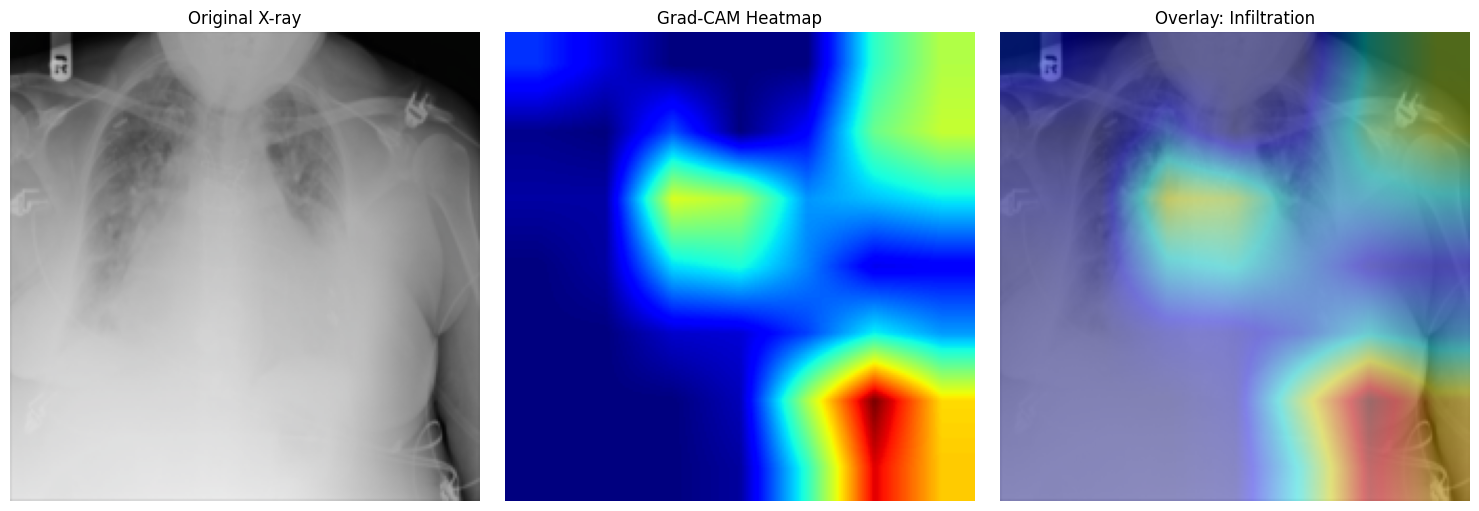

In [53]:
# convert the normalized tensor image back to a viewable format
img_display = image.permute(1, 2, 0).cpu().numpy()
img_display = img_display * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
img_display = np.clip(img_display, 0, 1)

# convert heatmap to color
heatmap_colored = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB) / 255.0

# overlay: blend original image and heatmap
overlay = 0.6 * img_display + 0.4 * heatmap_colored
overlay = np.clip(overlay, 0, 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img_display)
axes[0].set_title("Original X-ray")
axes[0].axis("off")

axes[1].imshow(cam, cmap="jet")
axes[1].set_title("Grad-CAM Heatmap")
axes[1].axis("off")

axes[2].imshow(overlay)
axes[2].set_title(f"Overlay: {unique_labels[target_class]}")
axes[2].axis("off")

plt.tight_layout()
plt.savefig("gradcam_example.png", dpi=150)
plt.show()

Image 5 — Predicted: No Finding, confidence: 0.809


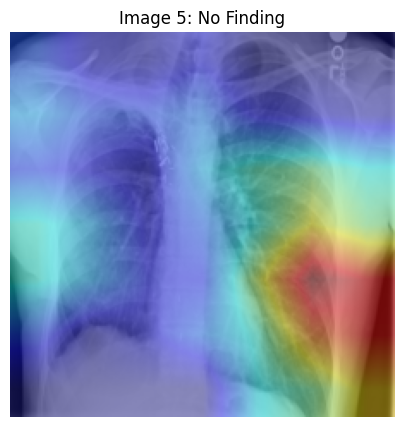

Image 20 — Predicted: No Finding, confidence: 0.751


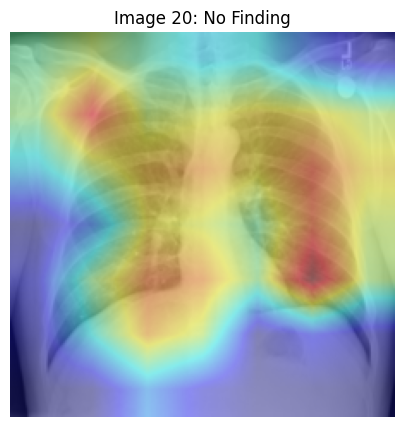

Image 50 — Predicted: Consolidation, confidence: 0.796


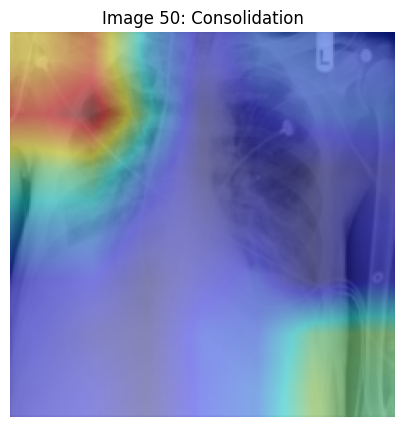

In [54]:
for i in [5, 20, 50]:  # a few different validation images
    image, label = val_dataset[i]
    input_tensor = image.unsqueeze(0).to(device)
    input_tensor.requires_grad_(True)

    output = model(input_tensor)
    probs = torch.sigmoid(output)
    target_class = torch.argmax(probs).item()
    print(f"Image {i} — Predicted: {unique_labels[target_class]}, confidence: {probs[0][target_class]:.3f}")

    model.zero_grad()
    output[0, target_class].backward()

    weights = gradients.mean(dim=(2, 3), keepdim=True)
    cam = (weights * activations).sum(dim=1, keepdim=True)
    cam = torch.relu(cam)
    cam = cam.squeeze().cpu().detach().numpy()
    cam = cv2.resize(cam, (224, 224))
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

    img_display = image.permute(1, 2, 0).cpu().numpy()
    img_display = img_display * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img_display = np.clip(img_display, 0, 1)

    heatmap_colored = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB) / 255.0
    overlay = np.clip(0.6 * img_display + 0.4 * heatmap_colored, 0, 1)

    plt.figure(figsize=(5, 5))
    plt.imshow(overlay)
    plt.title(f"Image {i}: {unique_labels[target_class]}")
    plt.axis("off")
    plt.savefig(f"gradcam_example_{i}.png", dpi=150)
    plt.show()

In [55]:
model.fc = torch.nn.Linear(in_features=512, out_features=15).to(device)

# freeze everything first
for name, param in model.named_parameters():
    param.requires_grad = False

# then selectively unfreeze layer4 and fc
for name, param in model.named_parameters():
    if "layer4" in name or "fc" in name:
        param.requires_grad = True

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Trainable params: {trainable:,} / {total:,}")

Trainable params: 8,401,423 / 11,184,207


In [56]:
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_train_capped)
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.0001)

In [57]:
num_epochs = 10

model.train()

for epoch in range(num_epochs):
    print(f"Epoch {epoch+1}/{num_epochs}")
    running_loss = 0.0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    print(f"Loss: {epoch_loss:.4f}")

Epoch 1/10


sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.


Loss: 0.9357
Epoch 2/10
Loss: 0.6286
Epoch 3/10
Loss: 0.3999
Epoch 4/10
Loss: 0.2436
Epoch 5/10
Loss: 0.1438
Epoch 6/10
Loss: 0.0877
Epoch 7/10
Loss: 0.0568
Epoch 8/10
Loss: 0.0416
Epoch 9/10
Loss: 0.0323
Epoch 10/10
Loss: 0.0246


In [58]:
model.eval()

all_labels = []
all_probs = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        probs = torch.sigmoid(outputs)

        all_labels.append(labels.cpu().numpy())
        all_probs.append(probs.cpu().numpy())

all_labels = np.concatenate(all_labels, axis=0)
all_probs = np.concatenate(all_probs, axis=0)
all_preds = (all_probs >= 0.4).astype(int)

precision, recall, f1, support = precision_recall_fscore_support(
    all_labels, all_preds, average=None, zero_division=0
)

auc_scores = []
for i in range(len(unique_labels)):
    try:
        auc = roc_auc_score(all_labels[:, i], all_probs[:, i])
    except ValueError:
        auc = float("nan")
    auc_scores.append(auc)

print(f"{'Disease':<20}{'Precision':<12}{'Recall':<12}{'F1':<12}{'AUC':<12}{'Support'}")
for i, label in enumerate(unique_labels):
    print(f"{label:<20}{precision[i]:<12.3f}{recall[i]:<12.3f}{f1[i]:<12.3f}{auc_scores[i]:<12.3f}{support[i]}")

Disease             Precision   Recall      F1          AUC         Support
Atelectasis         0.270       0.236       0.252       0.701       72
Cardiomegaly        0.000       0.000       0.000       0.715       19
Consolidation       0.000       0.000       0.000       0.701       31
Edema               0.000       0.000       0.000       0.756       16
Effusion            0.301       0.247       0.272       0.782       89
Emphysema           0.000       0.000       0.000       0.812       19
Fibrosis            0.000       0.000       0.000       0.554       15
Hernia              0.000       0.000       0.000       0.691       2
Infiltration        0.350       0.240       0.285       0.644       150
Mass                0.304       0.152       0.203       0.638       46
No Finding          0.665       0.765       0.712       0.721       452
Nodule              0.292       0.125       0.175       0.666       56
Pleural_Thickening  0.000       0.000       0.000       0.603       38


In [60]:
model = models.resnet18(weights="IMAGENET1K_V1")
model.fc = torch.nn.Linear(in_features=512, out_features=15)
model = model.to(device)

for name, param in model.named_parameters():
    param.requires_grad = False

for name, param in model.named_parameters():
    if "layer4" in name or "fc" in name:
        param.requires_grad = True

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_train_capped)
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.0001)

num_epochs = 4
model.train()

for epoch in range(num_epochs):
    print(f"Epoch {epoch+1}/{num_epochs}")
    running_loss = 0.0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    print(f"Loss: {epoch_loss:.4f}")

Epoch 1/4
Loss: 0.9498
Epoch 2/4
Loss: 0.6335
Epoch 3/4
Loss: 0.4123
Epoch 4/4
Loss: 0.2506


In [64]:
model.eval()

all_labels = []
all_probs = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        probs = torch.sigmoid(outputs)

        all_labels.append(labels.cpu().numpy())
        all_probs.append(probs.cpu().numpy())

all_labels = np.concatenate(all_labels, axis=0)
all_probs = np.concatenate(all_probs, axis=0)
all_preds = (all_probs >= 0.4).astype(int)

precision, recall, f1, support = precision_recall_fscore_support(
    all_labels, all_preds, average=None, zero_division=0
)

auc_scores = []
for i in range(len(unique_labels)):
    try:
        auc = roc_auc_score(all_labels[:, i], all_probs[:, i])
    except ValueError:
        auc = float("nan")
    auc_scores.append(auc)

print(f"{'Disease':<20}{'Precision':<12}{'Recall':<12}{'F1':<12}{'AUC':<12}{'Support'}")
for i, label in enumerate(unique_labels):
    print(f"{label:<20}{precision[i]:<12.3f}{recall[i]:<12.3f}{f1[i]:<12.3f}{auc_scores[i]:<12.3f}{support[i]}")

Disease             Precision   Recall      F1          AUC         Support
Atelectasis         0.180       0.556       0.272       0.727       72
Cardiomegaly        0.091       0.053       0.067       0.789       19
Consolidation       0.077       0.194       0.110       0.717       31
Edema               0.100       0.062       0.077       0.764       16
Effusion            0.216       0.539       0.309       0.759       89
Emphysema           0.158       0.158       0.158       0.852       19
Fibrosis            0.000       0.000       0.000       0.520       15
Hernia              0.000       0.000       0.000       0.659       2
Infiltration        0.234       0.733       0.355       0.663       150
Mass                0.188       0.283       0.226       0.650       46
No Finding          0.647       0.743       0.692       0.710       452
Nodule              0.158       0.375       0.222       0.667       56
Pleural_Thickening  0.138       0.105       0.119       0.613       38


In [66]:
print(cam.shape, cam.dtype)
print("min:", cam.min(), "max:", cam.max())
print("any NaN:", np.isnan(cam).any())

(224, 224, 7) float32
min: 0.0 max: 0.999157
any NaN: False


In [67]:
print("activations shape:", activations.shape)
print("gradients shape:", gradients.shape)
print("weights shape:", weights.shape)

cam = (weights * activations).sum(dim=1, keepdim=True)
print("cam shape after sum:", cam.shape)

cam = torch.relu(cam)
cam = cam.squeeze()
print("cam shape after squeeze:", cam.shape)

cam = cam.cpu().detach().numpy()
print("cam shape as numpy:", cam.shape)

activations shape: torch.Size([27, 512, 7, 7])
gradients shape: torch.Size([27, 512, 7, 7])
weights shape: torch.Size([27, 512, 1, 1])
cam shape after sum: torch.Size([27, 1, 7, 7])
cam shape after squeeze: torch.Size([27, 7, 7])
cam shape as numpy: (27, 7, 7)


Predicted class: Infiltration, confidence: 0.735
cam shape (should be 7,7): (7, 7)


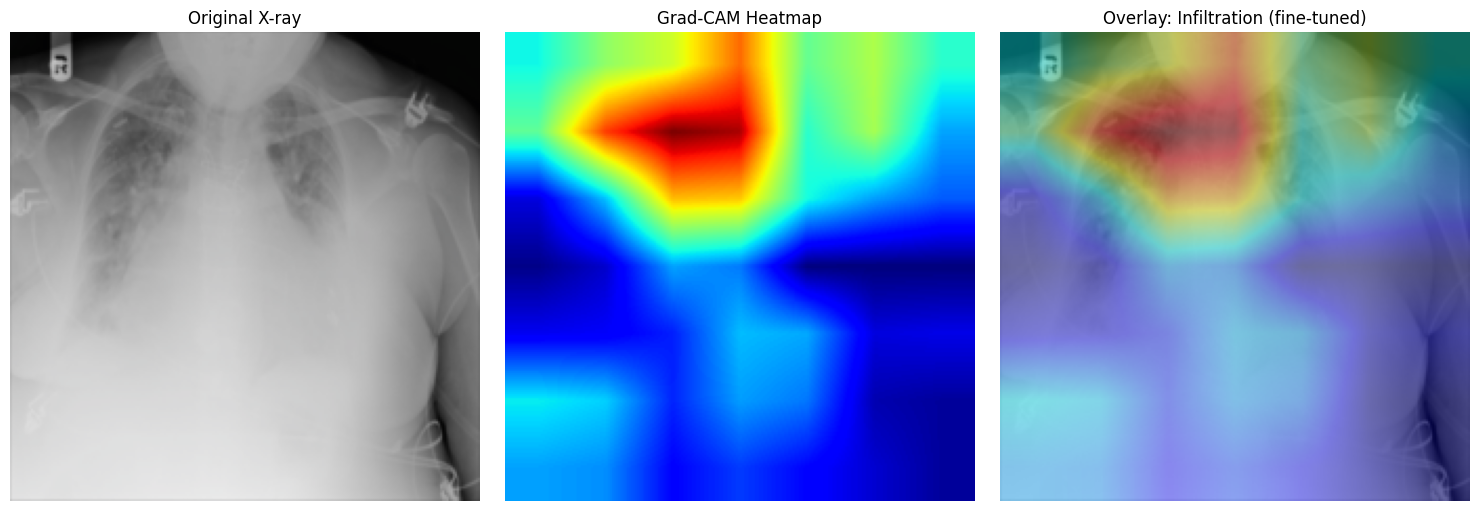

In [71]:
target_layer = model.layer4
target_layer.register_forward_hook(forward_hook)
target_layer.register_full_backward_hook(backward_hook)

model.eval()

image, label = val_dataset[0]
input_tensor = image.unsqueeze(0).to(device)
input_tensor.requires_grad_(True)

output = model(input_tensor)
probs = torch.sigmoid(output)
target_class = torch.argmax(probs).item()
print(f"Predicted class: {unique_labels[target_class]}, confidence: {probs[0][target_class]:.3f}")

model.zero_grad()
output[0, target_class].backward()

weights = gradients.mean(dim=(2, 3), keepdim=True)
cam = (weights * activations).sum(dim=1, keepdim=True)
cam = torch.relu(cam)
cam = cam.squeeze().cpu().detach().numpy()
print("cam shape (should be 7,7):", cam.shape)

cam = cv2.resize(cam, (224, 224))

img_display = image.permute(1, 2, 0).cpu().numpy()
img_display = img_display * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
img_display = np.clip(img_display, 0, 1)

cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
heatmap_colored = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB) / 255.0
overlay = np.clip(0.6 * img_display + 0.4 * heatmap_colored, 0, 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img_display); axes[0].set_title("Original X-ray"); axes[0].axis("off")
axes[1].imshow(cam, cmap="jet"); axes[1].set_title("Grad-CAM Heatmap"); axes[1].axis("off")
axes[2].imshow(overlay); axes[2].set_title(f"Overlay: {unique_labels[target_class]} (fine-tuned)"); axes[2].axis("off")
plt.tight_layout()
plt.savefig("gradcam_finetuned_example.png", dpi=150)
plt.show()